# Import Libraries


In [1]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


sns.set(style='whitegrid', palette='muted', font_scale=1.1)

#  Load Dataset and Inspect

In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/saurabhshahane/road-traffic-accidents/RTA Dataset.csv') 

# Display top 5 rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
# Observation:
#The dataset contains features related to driver, vehicle, road, and environmental conditions.
# Target variable is `Accident_severity`. Some columns may contain missing values or inconsistencies.

#  Statistical Analysis

In [4]:
# Check data info and types
df.info()

# Check numeric statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [5]:
# Observations:
#- Identify numeric and categorical columns.
#- Many categorical features have missing values (e.g., Age_band_of_driver, Educational_level).
#- Some numeric columns may have missing values (e.g., Number_of_casualties).
#- Cleaning is required for preprocessing.

# Visual Analysis

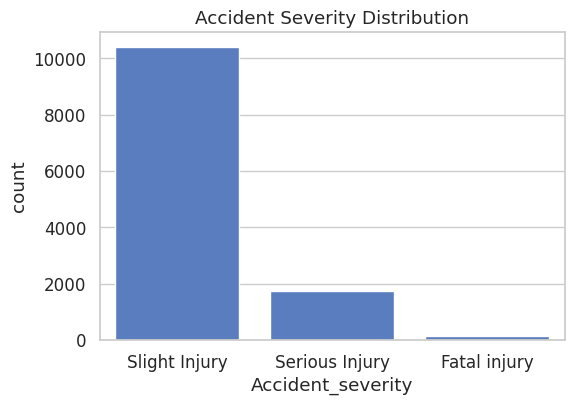

In [6]:
#Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_severity', data=df)
plt.title('Accident Severity Distribution')
plt.show()

In [7]:
# Observation:
# Most accidents are of Slight Injury type; Serious Injury accidents are less frequent. This imbalance may affect model performance.

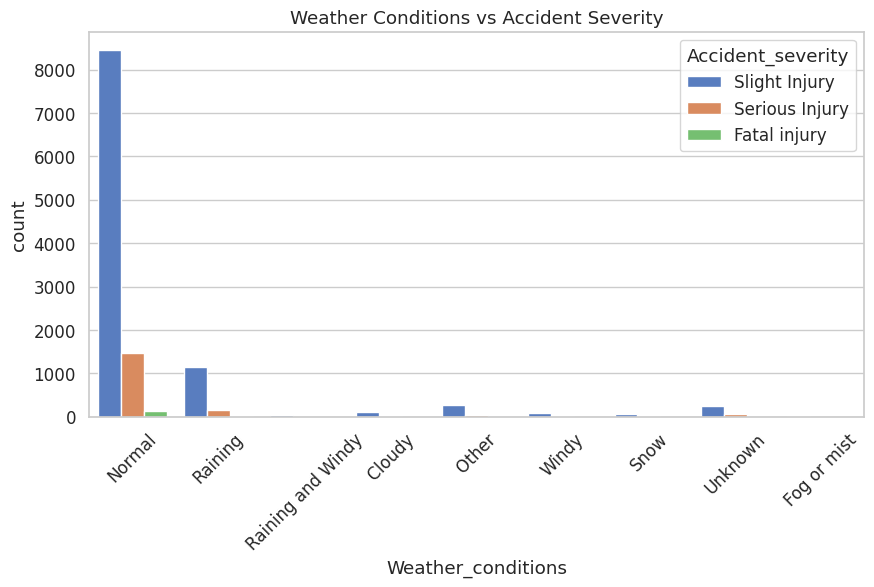

In [8]:
# Weather Conditions vs Accident Severity
plt.figure(figsize=(10,5))
sns.countplot(x='Weather_conditions', hue='Accident_severity', data=df)
plt.title('Weather Conditions vs Accident Severity')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Observation:
# Certain weather conditions like Raining or Wet/Damp roads have higher proportion of serious injuries.

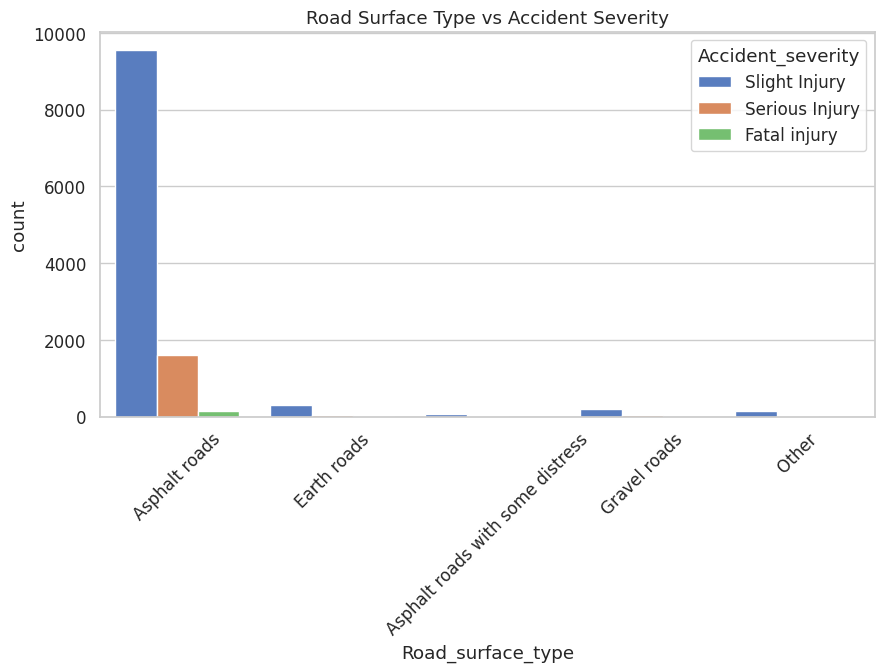

In [10]:
# Road Type vs Accident Severity
plt.figure(figsize=(10,5))
sns.countplot(x='Road_surface_type', hue='Accident_severity', data=df)
plt.title('Road Surface Type vs Accident Severity')
plt.xticks(rotation=45)
plt.show()

In [11]:
# Observation:
# Accidents on Earth or Gravel roads tend to have more severe outcomes.

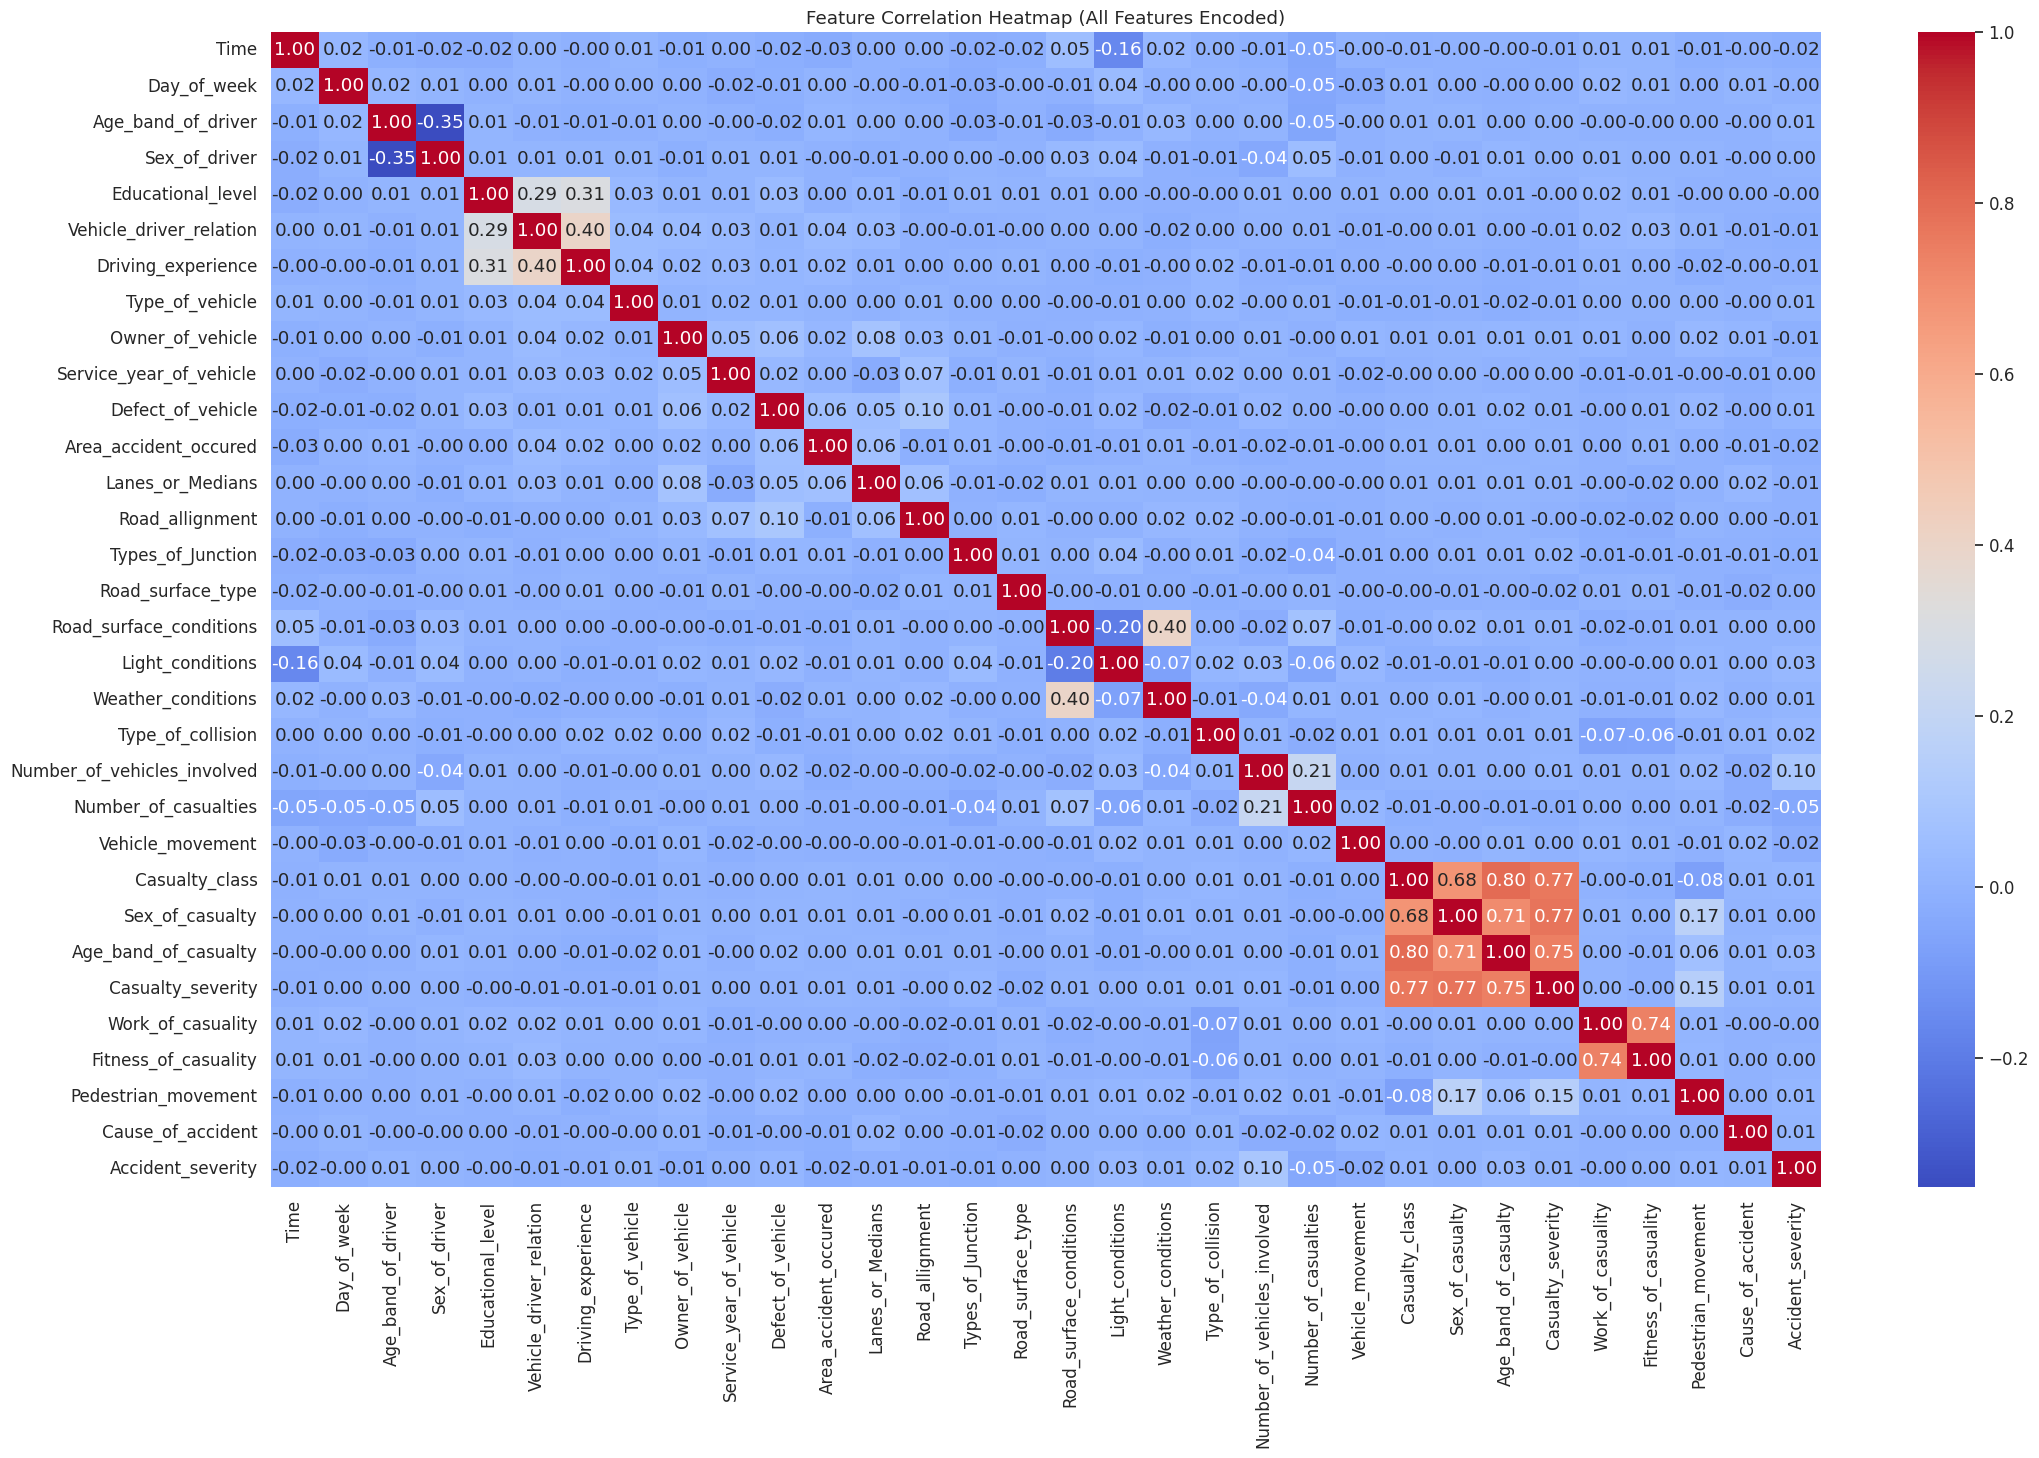

In [12]:
# Feature Correlation

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

plt.figure(figsize=(25,15))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap (All Features Encoded)")
plt.show()

# Preprocessing

In [13]:
# Handle Missing Values
# Fill categorical features with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
   # print(f"{col} missing values filled with mode.")

# Fill numeric features with median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())
    # print(f"{col} missing values filled with median.")

In [14]:
# Reason:
# Categorical features cannot have missing values for ML. Numeric missing values are filled with median to reduce the effect of outliers.

In [15]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
   # print(f"{col} encoded.")

In [16]:
# Reason:
# Machine learning models require numeric inputs. Label encoding converts categories to numeric labels while preserving information.

In [17]:
# Drop Irrelevant Columns
# Drop identifier or redundant columns if any
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)
    # print("Time column dropped as not needed for modeling.")

In [18]:
# Reason:
# Time may not provide predictive power for accident severity and can be ignored in this phase.

In [19]:
# Save Preprocessed Dataset
df.to_csv('RTA_Cleaned.csv', index=False)
print("Preprocessed dataset saved as RTA_Cleaned.csv.")

Preprocessed dataset saved as RTA_Cleaned.csv.


# Feature Engineering

In [20]:
# Load Preprocessed Dataset
df = pd.read_csv('/kaggle/working/RTA_Cleaned.csv')
df.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,1,0,1,0,0,0,0,3,3,2,...,2,3,2,5,3,0,2,5,9,2
1,1,1,1,4,0,3,11,3,2,2,...,2,3,2,5,3,0,2,5,16,2
2,1,0,1,4,0,0,5,3,5,2,...,2,0,1,1,2,0,2,5,0,1
3,3,0,1,4,0,2,11,0,5,2,...,2,2,0,0,2,0,2,5,1,2
4,3,0,1,4,0,1,0,3,2,2,...,2,3,2,5,3,0,2,5,16,2


In [21]:
# Prepare Data
X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

In [22]:
#    Feature Importance Using 5 Algorithms

# We will use:   Random Forest  Decision Tree   Logistic Regression   LightGBM   Extra Tree

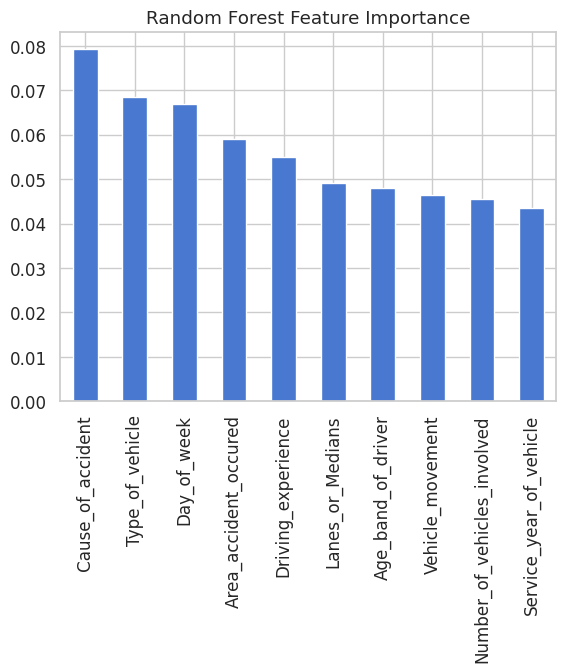

In [23]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.show()

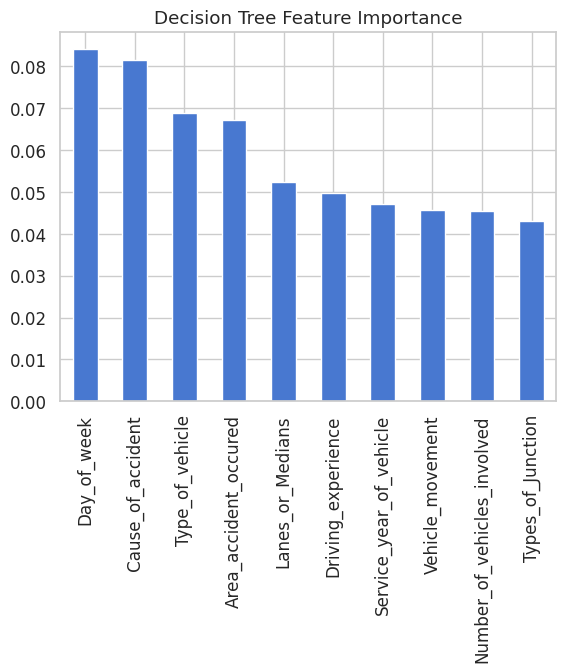

In [24]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X, y)

dt_importance = pd.Series(dt.feature_importances_, index=X.columns)
dt_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Decision Tree Feature Importance")
plt.show()

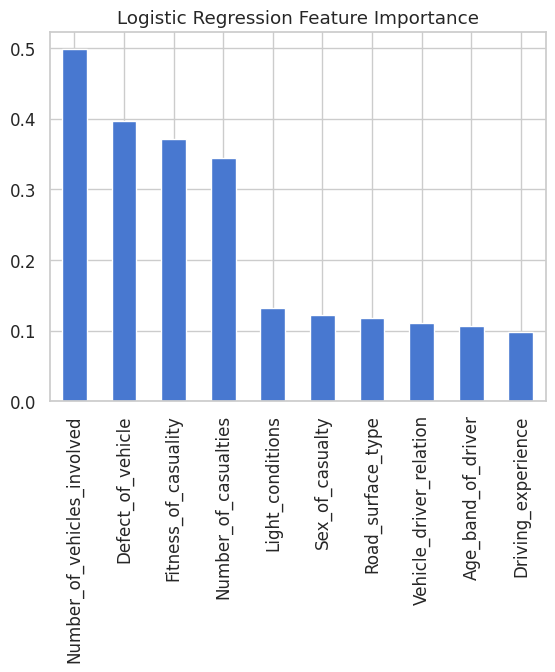

In [25]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

importance = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Logistic Regression Feature Importance")
plt.show()

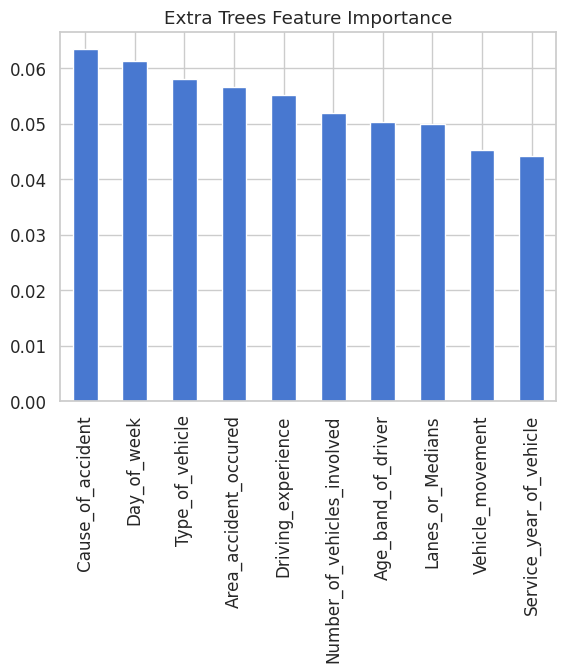

In [26]:
#Extra Trees

et = ExtraTreesClassifier()
et.fit(X, y)

et_importance = pd.Series(et.feature_importances_, index=X.columns)
et_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Extra Trees Feature Importance")
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 12316, number of used features: 30
[LightGBM] [Info] Start training from score -4.356059
[LightGBM] [Info] Start training from score -1.955291
[LightGBM] [Info] Start training from score -0.167652


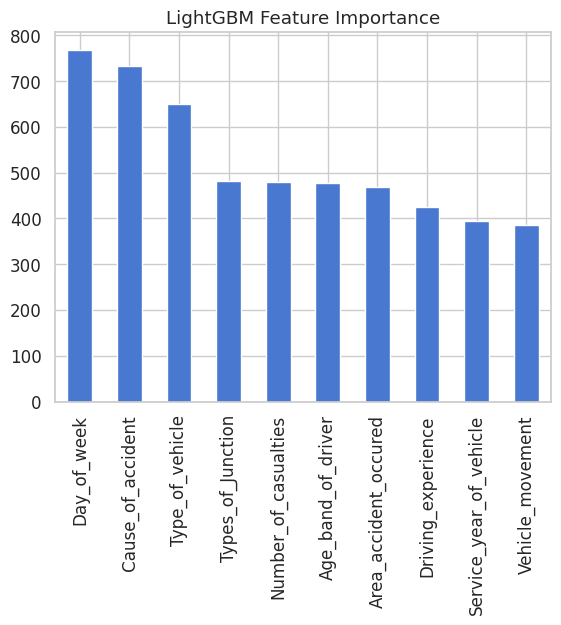

In [27]:
# LightGBM 
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X, y)

lgb_importance = pd.Series(lgb_model.feature_importances_, index=X.columns)
lgb_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("LightGBM Feature Importance")
plt.show()

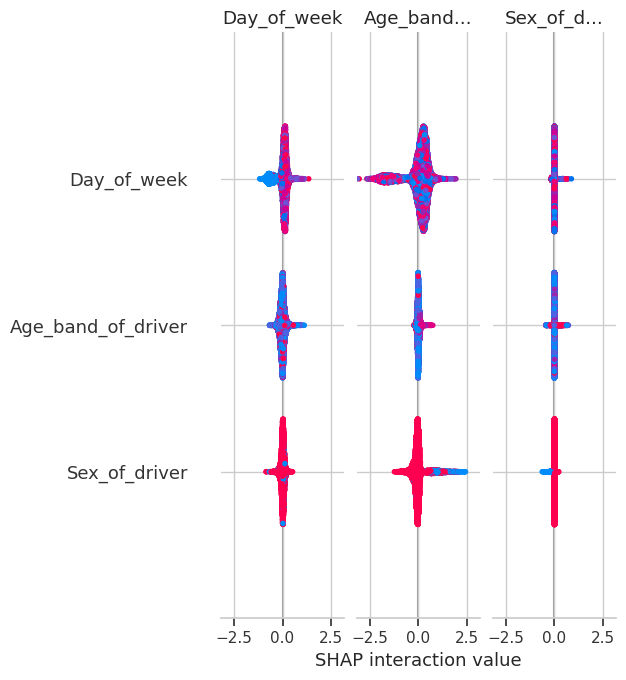

In [28]:
# SHAP Feature Importance
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [29]:
# SHAP helps explain how each feature contributes to model predictions and identifies the most influential features affecting accident severity.

In [30]:
# Create New Meaningful Features

In [31]:
# Feature 1: Casualties per Vehicle
df['casualty_per_vehicle'] = df['Number_of_casualties'] / (df['Number_of_vehicles_involved'] + 1)

# Reason:
# Accidents with more casualties relative to vehicles may indicate higher severity.

In [32]:
# Feature 2: Accident Complexity
df['accident_complexity'] = df['Number_of_casualties'] * df['Number_of_vehicles_involved']

# Reason:
# Combines casualties and vehicles to measure accident impact.

In [33]:
# Feature 3: Driver Experience Risk
df['experience_risk'] = df['Driving_experience'] * df['Age_band_of_driver']

# Reason:
# Driver age and experience together may influence accident severity.

In [34]:
# Test New Features with LightGBM
X_new = df.drop('Accident_severity', axis=1)
y_new = df['Accident_severity']

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

model = lgb.LGBMClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 275
[LightGBM] [Info] Number of data points in the train set: 9852, number of used features: 33
[LightGBM] [Info] Start training from score -4.399639
[LightGBM] [Info] Start training from score -1.965591
[LightGBM] [Info] Start training from score -0.165293
Accuracy: 0.8457792207792207


In [35]:
# If accuracy improves, the newly created features are useful.
# The LightGBM model achieved an accuracy of 84.57% on the test dataset.
# This indicates that the engineered features and preprocessing steps helped improve the predictive performance of the model.

In [36]:
# Standardization

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

#Reason:
# Standardization ensures all features are on the same scale and improves ML model performance.

In [37]:
# K-Means for Creating New Feature

kmeans = KMeans(n_clusters=3, random_state=42)

df['traffic_cluster'] = kmeans.fit_predict(df[['Number_of_vehicles_involved','Number_of_casualties']])

In [38]:
# Reason:

#  K-Means groups accidents into clusters based on traffic conditions.

#  This new feature helps the model identify accident patterns.

In [39]:
# Drop Less Important Features 
df = df.drop(['Service_year_of_vehicle'], axis=1)

# Reason:

# The feature showed very low importance in multiple algorithms, so removing it may reduce noise.

In [40]:
# Save Final Dataset
df.to_csv("RTA_FeatureEngineered.csv", index=False)